# **Radioactive Decay and Projectile Motion**







# Radioactive Decay

There are two species of radioactive particles $A$ and $B$. Consider two situations:

1. $A$ decays into $B$ and $B$ decays into $A$. The time constants for the species are $\tau_A$ and $\tau_B$
respectively. Set up and solve the ODEs by Euler’s method for the initial conditions
$N_A(0) = 100$, $N_B(0) = 0$. Can you make an argument for why the behaviour of the
solutions depend on $\tau_A/\tau_B $ ? Plot $N_A(t)$ and $N_B(t)$ vs $t$ for the following values of the
ration $\tau_A/\tau_B = 0.2, 1.0, 2.2$. Are the results as expected (and why)?

2. A decays into $B$, which decays also (but not into $A$). For simplicity, take a common
time constant $\tau=1$. Solve the solutions and show that they reach a constant value
asymptotically.

Why does the solution in (a) reach a constant non-zero equilibrium eventually and the
solution in (b) does not?





#Hand Analysis
The rate of decay of $A$ can be written as :

$$
  \frac{dN_A}{dt}=-\frac{N_A}{\tau_A} + \frac{N_B}{\tau_B}
$$

Also, we can simillarly write for rate of decay of $B$ as,

$$
  \frac{dN_B}{dt}=-\frac{N_B}{\tau_B} + \frac{N_A}{\tau_A}
$$

As, the total quantity remains same,Hence rate of change of $A$ and rate of change of $B$ will be $0$ ie,

$$
\frac{dN_A}{dt}+\frac{dN_B}{dt}=0
$$

On simplyifing, we get:

$$\frac{N_A}{N_B}=\frac{\tau_A}{\tau_B}$$

Now, we get into two conclusions,


1.   $\frac{\tau_A}{\tau_B} > 1$ ie $A$ is more stable than $B$.Hence, at equilibrium $A$ is in more amount than $B$.

2.    $\frac{\tau_A}{\tau_B} < 1$ ie $B$ is more stable than $A$.Hence, at equilibrium $B$ is in more amount than $A$.

No we implement the Euler's theorem.
Hence, we get
$$
N_A(t_o+h) = N_A(t_o) + \frac{dN_A}{dt}h
$$

$$
N_B(t_o+h) = N_B(t_o) + \frac{dN_B}{dt}h
$$




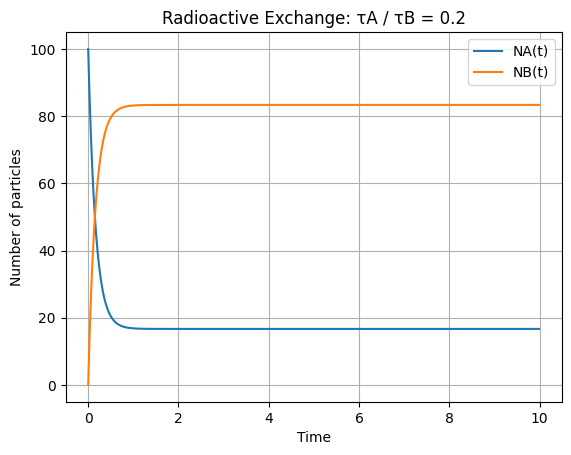

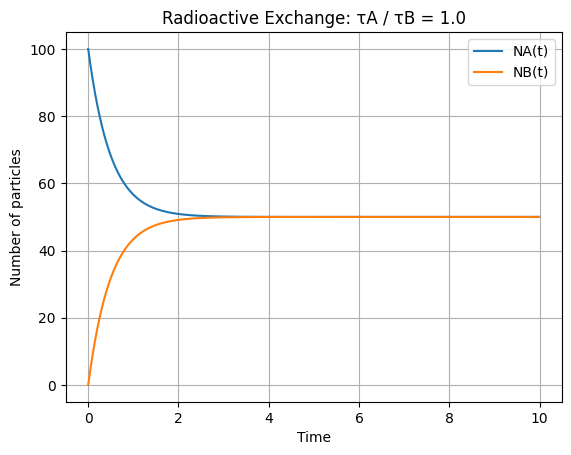

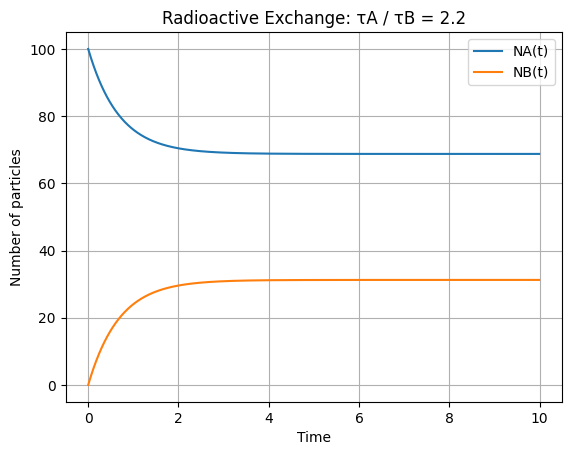

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

NA0, NB0 = 100.0, 0.0
t0, tf = 0.0, 10.0
dt = 0.01
t = np.arange(t0, tf, dt)

def euler_decay(tauA, tauB):
    NA = np.zeros_like(t)
    NB = np.zeros_like(t)
    NA[0], NB[0] = NA0, NB0

    for i in range(len(t)-1):
        NA[i+1] = NA[i] + dt * (-NA[i]/tauA + NB[i]/tauB)
        NB[i+1] = NB[i] + dt * ( NA[i]/tauA - NB[i]/tauB)

    return NA, NB

ratios = [0.2, 1.0, 2.2]
tauB = 1.0

for r in ratios:
    tauA = r * tauB
    NA, NB = euler_decay(tauA, tauB)

    plt.figure()
    plt.plot(t, NA, label="NA(t)")
    plt.plot(t, NB, label="NB(t)")
    plt.xlabel("Time")
    plt.ylabel("Number of particles")
    plt.title(f"Radioactive Exchange: τA / τB = {r}")
    plt.legend()
    plt.grid()
    plt.show()

## Hand Analysis
The rate of change of particle $A$ will be,
$$\frac{dN_A}{dt}=-N_A$$

Simillarly, The rate of change of $B$ will be,

$$\frac{dN_B}{dt}=N_A-N_B$$

Hence, according to the Euler's formula

$$
N_A(t_o+h) = N_A(t_o) + \frac{dN_A}{dt}h
$$

$$
N_B(t_o+h) = N_B(t_o) + \frac{dN_B}{dt}h
$$

The initial values are
$$N_A(0)=100, N_B(0)=0$$

##Observations

1. When $\frac{\tau_A}{\tau_B} = 0.2$ ie $<1$, The amount of $A$ is less stable than amount of $B$.
2. When $\frac{\tau_A}{\tau_B} = 1$, The amount of $A$ and $B$ are same.
3. When $\frac{\tau_A}{\tau_B} = 2.2$ ie $>1$, The amount of $A$ is more stable than amount of $B$.





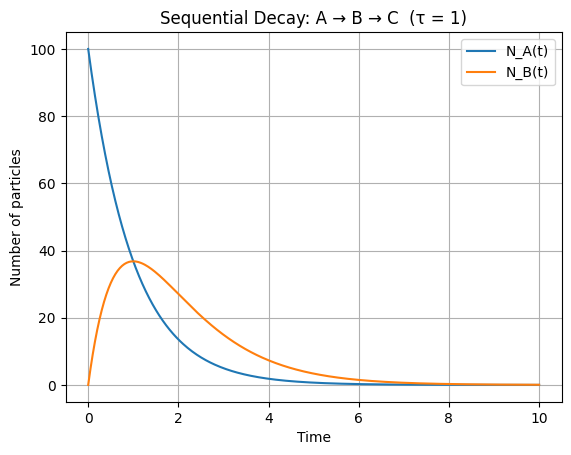

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
t = np.linspace(0, 10, 400)
NA = 100 * np.exp(-t)
NB = 100 * t * np.exp(-t)
plt.figure()
plt.plot(t, NA, label="N_A(t)")
plt.plot(t, NB, label="N_B(t)")
plt.xlabel("Time")
plt.ylabel("Number of particles")
plt.title("Sequential Decay: A → B → C  (τ = 1)")
plt.legend()
plt.grid()
plt.show()


#Observations
1) Initially the quantity of $B$ increases as $A$ decays into $B$ while $B$ decays into some other quantity $C$.
2) At t=$1$ the quanitity of $A$ equals $B$ , afterwards both the quantities decline till they reach $0$.
3) This is because the quantity of both $A$ and $B$ are not being replenished and are only decaying. Thus, the rate of decay of $A$ never equals the rate of gain of $A$.

###Why does the solution in $(a)$ reach a constant non-zero equilibrium eventually and the solution in $(b)$ does not?

This is because in $(a)$ , $A$ decays into $B$ while $B$ decays into $A$ . Over time the rate of decay of $A$ equals rate of decay of $B$ as the number of particles in the system remains constant. Therefore, the system reaches a non-zero equilibrium.

On the other hand, in $(b)$ , while $A$ decays into $B$ , $B$ does not decay into $A$ . Hence over time the quantity of both $A$ and $B$ reaches $0$. So the system does not reach equilibrium at a non zero quantity.


# Projectile Motion

Consider a particle projected at an angle $\theta$ with the x-axis from the origin, with a velocity
$v = 100 m/s$. Taking acceleration due to gravity $g = 10m/s$ and $B_2/m = 10^{-5}$
, Taking
three different values of $\theta$ (of your choice), plot the trajectory $x(t)$ vs $y(t)$ on the same
graph using Euler’s method. Also perform the same exercise without air resistance (i.e.,
$B_2 = 0m/s$) and plot $x(t)$ vs $y(t)$. Remark on the differences between the graphs.

## Hand Analysis
We study the motion of a projectile launched with an initial velocity $v_o$ at an angle $\theta$ with the horizontal.
The projectile moves under the influence of gravity and linear air resistance.

- Gravitational force acts downward
- Air resistance force is proportional to velocity and acts opposite to motion
$$
\frac{dv_x}{dt} = -\frac{b}{m} v_x
$$
$$
\frac{dx}{dt} = v_x
$$

$$
\frac{dv_y}{dt} = -g - \frac{b}{m} v_y
$$

$$
\frac{dy}{dt} = v_y
$$

The Initial conditions are:
$$x(0) = 0,\quad y(0) = 0 $$

$$
v_x(0) = v_0 \cos \theta
$$

$$
v_y(0) = v_0 \sin \theta
$$
For a general equation,

$$
\frac{df}{dt} = F(f,t)
$$

Euler method approximation:

$$
f(t+\Delta t) = f(t) + ht \cdot F(f,t)
$$

Now the horizontal velocity will be:

$$
v_x(t_o+h)= v_x(t_o) - \frac{b}{m} v_x^n h t
$$

Thus,the horizontal distance will be:

$$
x(t_o+h) = x(t_o) + v_x(t_o) ht
$$

The vertical velocity will be:
$$
v_y(t_o+h) = v_y(t_o) + \left(-g - \frac{b}{m} v_y^n \right)h t
$$
Thus the vertical distance will be:
$$
y(t_o+h)= y(t_o) + v_y(t_o) h t
$$
###Special Case: No Air Resistance

For $(b=0)$

$$
\frac{dv_x}{dt} = 0
$$

$$
\frac{dv_y}{dt} = -g
$$

This results in ideal parabolic motion.



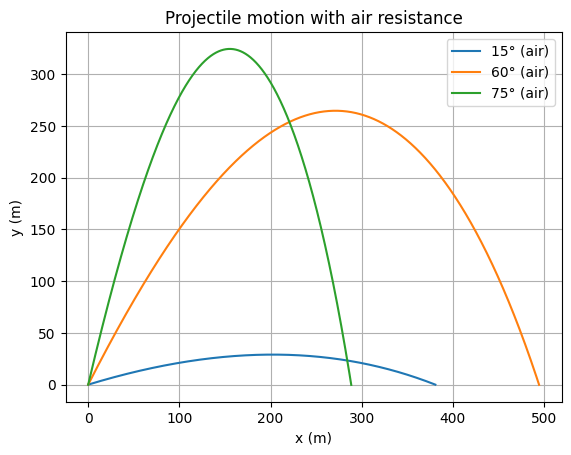

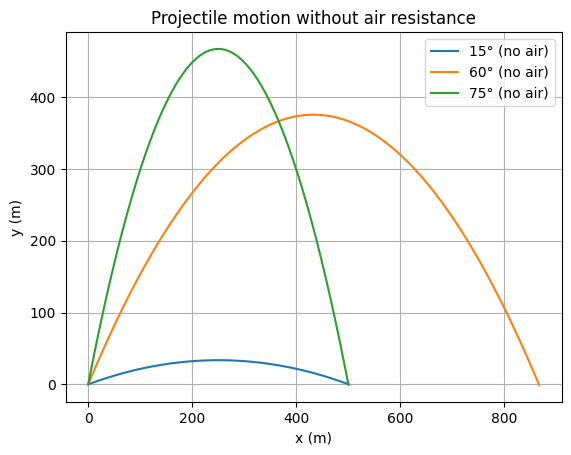

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
g = 10.0
v0 = 100.0
k_air = 0.001
dt = 0.01
thetas = [15, 60, 75]
def euler(theta, k):
    th = np.deg2rad(theta)
    x, y = 0.0, 0.0
    vx, vy = v0*np.cos(th), v0*np.sin(th)
    X, Y = [x], [y]

    while y >= 0:
        v = np.sqrt(vx**2 + vy**2)
        x += vx*dt
        y += vy*dt
        vx += -k*v*vx*dt
        vy += (-g - k*v*vy)*dt
        X.append(x); Y.append(y)
    return X, Y
plt.figure()
for t in thetas:
    x, y = euler(t, k_air)
    plt.plot(x, y, label=f"{t}° (air)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()
plt.title("Projectile motion with air resistance")
plt.grid()
plt.figure()
for t in thetas:
    x, y = euler(t, 0.0)
    plt.plot(x, y, label=f"{t}° (no air)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()
plt.title("Projectile motion without air resistance")
plt.grid()

plt.show()


## Observations


### 1. Symmetry and Geometry
* **Vacuum Case ($B_2 = 0$):** The trajectory is a perfectly symmetric parabola. The time taken to reach the apex is equal to the time taken to descend.
* **Air Resistance Case:** The symmetry is broken. The projectile follows a "truncated" path where the descent is much steeper than the ascent.



### 2. Impact on Range and Height
* **Range Reduction:** There is a noticeable decrease in the horizontal distance traveled. This occurs because the drag force $F_d \propto v^2$ constantly opposes the horizontal velocity $v_x$.
* **Apex Shift:** The maximum height reached is lower in the air resistance model, and the peak occurs earlier in the horizontal displacement.

### 3. Velocity and Terminal Behavior
* In the vacuum, $v_x$ remains constant throughout the flight.
* With air resistance, $v_x$ decays. As the particle falls, the drag force increasingly opposes gravity, leading the projectile toward a steeper, near-vertical impact angle compared to the vacuum's mirrored launch angle.